
# Lab 02: Making Training Work

The goal is to find out why BrokenNet does not train, then fix it one change at a time. Every stage uses the same data, the same seed and 50 epochs. The architecture (8 layers, 32 units, ReLU) is not changed.

## Stage 0: Baseline

The code below is copied from `lab02_starter.py` without changes.


In [1]:
import os

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

os.makedirs("figures", exist_ok=True)

In [2]:
# ---- Copied unchanged from lab02_starter.py ----

class BrokenNet(nn.Module):
    def __init__(self, depth=8, width=32, in_features=20):
        super().__init__()
        layers = []
        n_in = in_features
        for _ in range(depth):
            layers.append(nn.Linear(n_in, width))
            n_in = width
        self.hidden = nn.ModuleList(layers)
        self.out = nn.Linear(width, 1)

        for layer in self.hidden:
            nn.init.normal_(layer.weight, mean=0.0, std=0.3)
            nn.init.constant_(layer.bias, -2.0)

    def forward(self, x):
        for layer in self.hidden:
            x = torch.relu(layer(x))
        return self.out(x)


def make_toy_classification(n=256, in_features=20, seed=0):
    """A small synthetic binary classification task: a fixed random
    linear boundary in a 20-dimensional input space. Simple enough that
    a correctly trained network of this size should solve it easily.
    """
    g = torch.Generator().manual_seed(seed)
    x = torch.randn(n, in_features, generator=g)
    true_w = torch.randn(in_features, 1, generator=g)
    logits = x @ true_w
    y = (logits > 0).float().squeeze(-1)
    return x, y

In [3]:
# ---- The starter's __main__ block, unchanged ----
torch.manual_seed(0)
model = BrokenNet()
x, y = make_toy_classification(seed=0)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

print("Training BrokenNet for 50 epochs with plain SGD...")
for epoch in range(50):
    optimizer.zero_grad()
    preds = model(x).squeeze(-1)
    loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0 or epoch == 49:
        print(f"epoch {epoch:3d}   loss = {loss.item():.4f}")

print("\nFor reference, a model that has learned nothing at all scores")
print("about 0.693 on this loss (ln 2) — check whether the number above")
print("actually moved away from that.")

Training BrokenNet for 50 epochs with plain SGD...
epoch   0   loss = 0.7037
epoch  10   loss = 0.6974
epoch  20   loss = 0.6937
epoch  30   loss = 0.6914
epoch  40   loss = 0.6901
epoch  49   loss = 0.6893

For reference, a model that has learned nothing at all scores
about 0.693 on this loss (ln 2) — check whether the number above
actually moved away from that.



Observation: The loss went from 0.7037 to 0.6893 in 50 epochs. It stayed very close to 0.693, which is the loss you get from random guessing. The network is not learning.



## Diagnosis

Same check as the Week 2 module: run one forward and backward pass, then print the mean absolute gradient of each hidden layer. I also count how many ReLU outputs are exactly zero in each layer.


In [4]:

def per_layer_grad_norms(model):
    return [layer.weight.grad.abs().mean().item() for layer in model.hidden]


def gradient_check(model):
    model.zero_grad()
    preds = model(x).squeeze(-1)
    loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
    loss.backward()
    return per_layer_grad_norms(model)


torch.manual_seed(0)
model = BrokenNet()
grads = gradient_check(model)
for i, g in enumerate(grads):
    print(f"layer {i}: mean |gradient| = {g:.2e}")


layer 0: mean |gradient| = 0.00e+00
layer 1: mean |gradient| = 0.00e+00
layer 2: mean |gradient| = 0.00e+00
layer 3: mean |gradient| = 0.00e+00
layer 4: mean |gradient| = 0.00e+00
layer 5: mean |gradient| = 0.00e+00
layer 6: mean |gradient| = 0.00e+00
layer 7: mean |gradient| = 0.00e+00


layer 0: 93.3% of ReLU outputs are zero
layer 1: 99.9% of ReLU outputs are zero
layer 2: 100.0% of ReLU outputs are zero
layer 3: 100.0% of ReLU outputs are zero
layer 4: 100.0% of ReLU outputs are zero
layer 5: 100.0% of ReLU outputs are zero
layer 6: 100.0% of ReLU outputs are zero
layer 7: 100.0% of ReLU outputs are zero


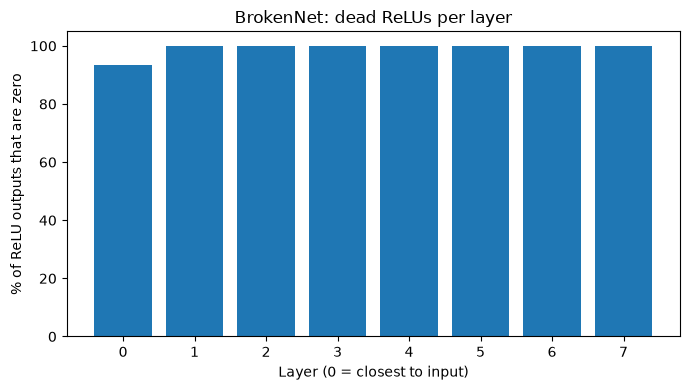

In [5]:

dead = []
h = x
with torch.no_grad():
    for i, layer in enumerate(model.hidden):
        h = torch.relu(layer(h))
        dead.append((h == 0).float().mean().item() * 100)
        print(f"layer {i}: {dead[-1]:.1f}% of ReLU outputs are zero")

plt.figure(figsize=(7, 4))
plt.bar(range(8), dead)
plt.xlabel("Layer (0 = closest to input)")
plt.ylabel("% of ReLU outputs that are zero")
plt.title("BrokenNet: dead ReLUs per layer")
plt.tight_layout()
plt.savefig("figures/stage0_dead_relus.png", dpi=150)
plt.show()


final loss: 0.6893


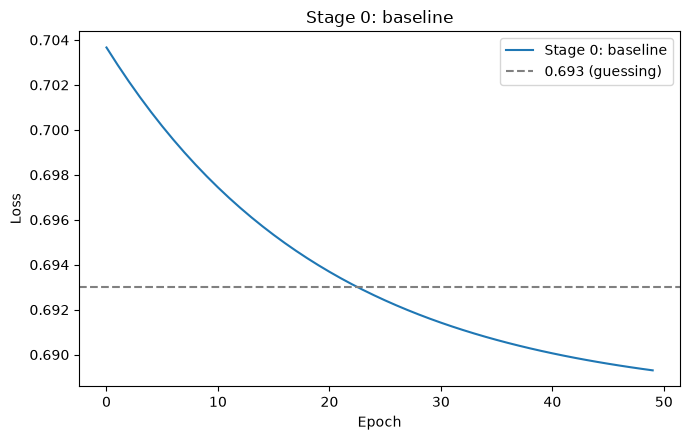

In [6]:

results = {}  # stage name -> list of losses
grad_results = {}  # stage name -> per-layer gradient before training


def train(model, optimizer, epochs=50):
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        preds = model(x).squeeze(-1)
        loss = nn.functional.binary_cross_entropy_with_logits(preds, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses


def plot_losses(names, title, filename):
    plt.figure(figsize=(7, 4.5))
    for name in names:
        plt.plot(results[name], label=name)
    plt.axhline(0.693, color="gray", linestyle="--", label="0.693 (guessing)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"figures/{filename}", dpi=150)
    plt.show()


torch.manual_seed(0)
model = BrokenNet()
grad_results["Stage 0: baseline"] = gradient_check(model)
results["Stage 0: baseline"] = train(model, torch.optim.SGD(model.parameters(), lr=0.1))
print(f"final loss: {results['Stage 0: baseline'][-1]:.4f}")
plot_losses(["Stage 0: baseline"], "Stage 0: baseline", "stage0_baseline.png")



Observation: The gradient is exactly 0 in all 8 hidden layers. The ReLU check shows why. 93% of the outputs in layer 0 are zero, and from layer 2 onwards 100% are zero.

Every hidden layer has a bias of -2, which pushes almost every value below zero. ReLU turns those values into 0, and its gradient is also 0 there. So no gradient gets back to any hidden layer. This is the dead ReLU problem, caused by the initialization. It is not a vanishing gradient, because the gradient is not just small, it is zero.

The loss still drops a little because the output bias can learn. It learns to always predict the more common class, and that stops at about 0.688.



## Stage 1: Optimizer only

Change: SGD is replaced with Adam (lr = 0.01). Everything else is the same as Stage 0.


final loss: 0.6880


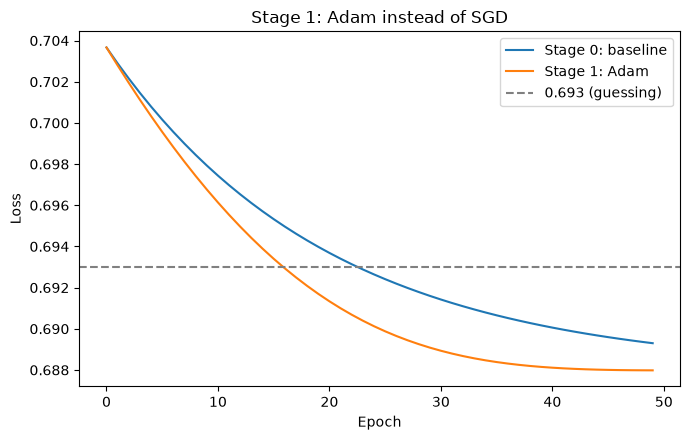

In [7]:

torch.manual_seed(0)
model = BrokenNet()
grad_results["Stage 1: Adam"] = gradient_check(model)
results["Stage 1: Adam"] = train(model, torch.optim.Adam(model.parameters(), lr=0.01))
print(f"final loss: {results['Stage 1: Adam'][-1]:.4f}")
plot_losses(["Stage 0: baseline", "Stage 1: Adam"], "Stage 1: Adam instead of SGD", "stage1_adam.png")



Observation: Adam did not help. The final loss is 0.6880, almost the same as the baseline. This makes sense because every optimizer uses the gradient to decide how to update the weights. The gradient is zero, so there is nothing for Adam to work with. The problem is not the optimizer, so I go back to SGD for the next stages.



## Stage 2: He initialization for the weights

Change: the hidden weights use He (Kaiming) initialization instead of normal with std 0.3. The bias is still -2.


final loss: 0.6893
layer 0 gradient: 0.00e+00


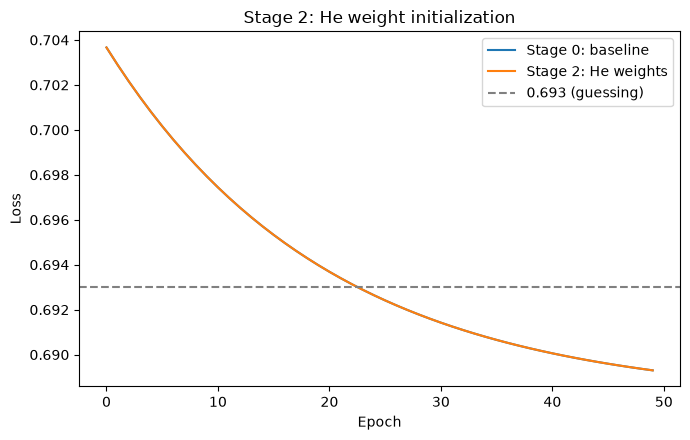

In [8]:

torch.manual_seed(0)
model = BrokenNet()
for layer in model.hidden:
    nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")

grad_results["Stage 2: He weights"] = gradient_check(model)
results["Stage 2: He weights"] = train(model, torch.optim.SGD(model.parameters(), lr=0.1))
print(f"final loss: {results['Stage 2: He weights'][-1]:.4f}")
print(f"layer 0 gradient: {grad_results['Stage 2: He weights'][0]:.2e}")
plot_losses(["Stage 0: baseline", "Stage 2: He weights"], "Stage 2: He weight initialization", "stage2_he_weights.png")



Observation: No change. The final loss is 0.6893, the same as the baseline, and the gradient is still 0. He initialization gives a weight std of about 0.25 to 0.32 for this network, which is very close to the original 0.3. So the weights were not the problem. The -2 bias is still making the ReLUs dead.



## Stage 3: Zero bias

Change: the hidden biases are set to 0 instead of -2. Together with Stage 2 this is the standard He initialization.


final loss: 0.3632
layer 0: mean |gradient| = 2.69e-03
layer 1: mean |gradient| = 3.39e-03
layer 2: mean |gradient| = 2.83e-03
layer 3: mean |gradient| = 2.89e-03
layer 4: mean |gradient| = 2.77e-03
layer 5: mean |gradient| = 2.40e-03
layer 6: mean |gradient| = 3.04e-03
layer 7: mean |gradient| = 3.41e-03


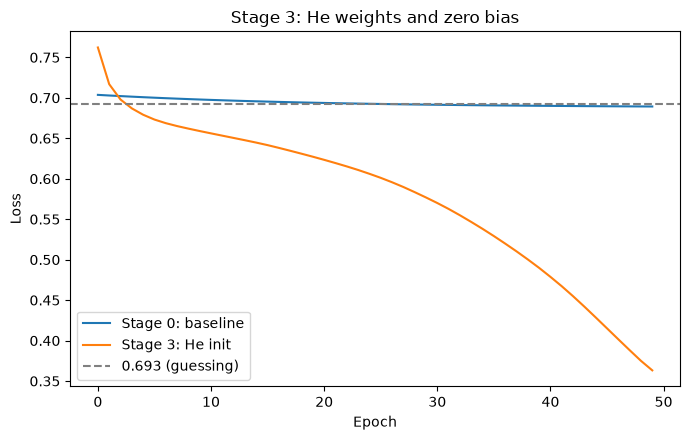

In [9]:

torch.manual_seed(0)
model = BrokenNet()
for layer in model.hidden:
    nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
    nn.init.zeros_(layer.bias)

grad_results["Stage 3: He init"] = gradient_check(model)
results["Stage 3: He init"] = train(model, torch.optim.SGD(model.parameters(), lr=0.1))
print(f"final loss: {results['Stage 3: He init'][-1]:.4f}")
for i, g in enumerate(grad_results["Stage 3: He init"]):
    print(f"layer {i}: mean |gradient| = {g:.2e}")
plot_losses(["Stage 0: baseline", "Stage 3: He init"], "Stage 3: He weights and zero bias", "stage3_zero_bias.png")



Observation: The network trains now. The final loss dropped to 0.3632, and every layer has a gradient of about 0.003 instead of 0. Without the -2 bias the values going into the ReLUs are centred around zero, so about half of the ReLUs are active and the gradient can flow back. This shows the -2 bias was the main cause of the problem.



## Stage 4: BatchNorm only

Change: a BatchNorm1d layer is added between each hidden Linear layer and its ReLU. The initialization is still the broken one (std 0.3, bias -2).


In [10]:

class BrokenNetBN(BrokenNet):
    """Same as BrokenNet (same layers and same initialization), with BatchNorm before each ReLU."""

    def __init__(self, depth=8, width=32, in_features=20):
        super().__init__(depth, width, in_features)
        self.norms = nn.ModuleList([nn.BatchNorm1d(width) for _ in range(depth)])

    def forward(self, x):
        for layer, norm in zip(self.hidden, self.norms):
            x = torch.relu(norm(layer(x)))
        return self.out(x)


final loss: 0.2437
layer 0: mean |gradient| = 5.78e-03
layer 1: mean |gradient| = 3.78e-03
layer 2: mean |gradient| = 3.46e-03
layer 3: mean |gradient| = 2.52e-03
layer 4: mean |gradient| = 2.13e-03
layer 5: mean |gradient| = 1.90e-03
layer 6: mean |gradient| = 1.67e-03
layer 7: mean |gradient| = 1.48e-03


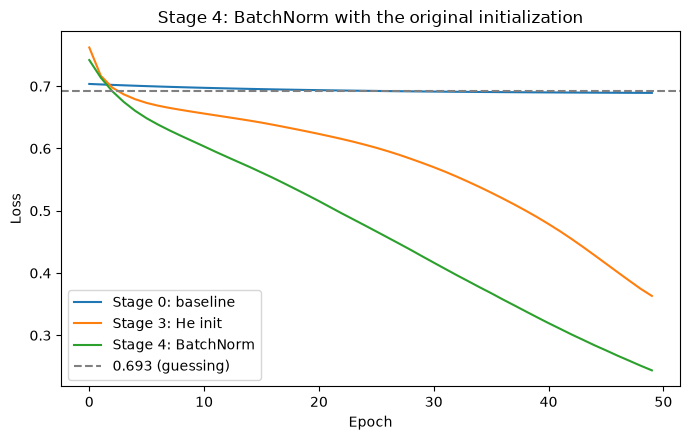

In [11]:

torch.manual_seed(0)
model = BrokenNetBN()

grad_results["Stage 4: BatchNorm"] = gradient_check(model)
results["Stage 4: BatchNorm"] = train(model, torch.optim.SGD(model.parameters(), lr=0.1))
print(f"final loss: {results['Stage 4: BatchNorm'][-1]:.4f}")
for i, g in enumerate(grad_results["Stage 4: BatchNorm"]):
    print(f"layer {i}: mean |gradient| = {g:.2e}")
plot_losses(["Stage 0: baseline", "Stage 3: He init", "Stage 4: BatchNorm"],
            "Stage 4: BatchNorm with the original initialization", "stage4_batchnorm.png")



Observation: BatchNorm fixed the network on its own, even with the -2 bias still there. The final loss is 0.2437, which is better than the He initialization fix (0.3632). BatchNorm subtracts the average of each unit before the ReLU. The -2 bias is added to every value, so it gets removed along with the average. The values are centred around zero again, so about half of the ReLUs are active and every layer gets a gradient.



## Stage 5: He initialization + BatchNorm

Change: add BatchNorm to the Stage 3 model.


final loss: 0.2276


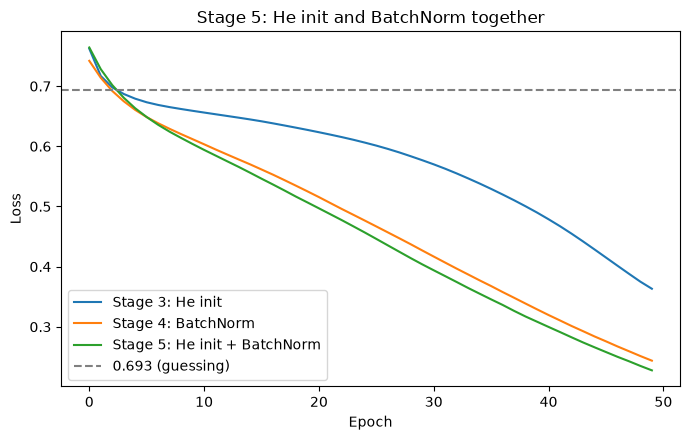

In [12]:

torch.manual_seed(0)
model = BrokenNetBN()
for layer in model.hidden:
    nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
    nn.init.zeros_(layer.bias)

grad_results["Stage 5: He init + BatchNorm"] = gradient_check(model)
results["Stage 5: He init + BatchNorm"] = train(model, torch.optim.SGD(model.parameters(), lr=0.1))
print(f"final loss: {results['Stage 5: He init + BatchNorm'][-1]:.4f}")
plot_losses(["Stage 3: He init", "Stage 4: BatchNorm", "Stage 5: He init + BatchNorm"],
            "Stage 5: He init and BatchNorm together", "stage5_combined.png")



Observation: The combination reached 0.2276, only a little better than BatchNorm alone (0.2437). BatchNorm had already removed the effect of the bad bias, so fixing the initialization as well did not add much. The loss is still going down at epoch 50, so plain SGD is now what slows training down.



## Stage 6: Adam on the fixed network

Change: SGD is replaced with Adam (lr = 0.01), the same change as Stage 1.


final loss: 0.0009


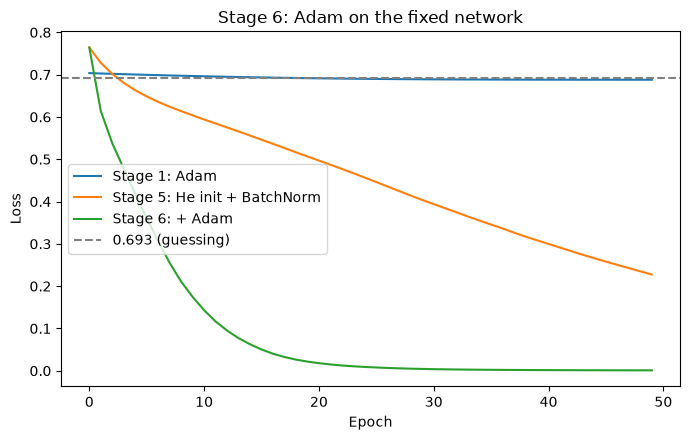

In [13]:

torch.manual_seed(0)
model = BrokenNetBN()
for layer in model.hidden:
    nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")
    nn.init.zeros_(layer.bias)

grad_results["Stage 6: + Adam"] = gradient_check(model)
results["Stage 6: + Adam"] = train(model, torch.optim.Adam(model.parameters(), lr=0.01))
print(f"final loss: {results['Stage 6: + Adam'][-1]:.4f}")
plot_losses(["Stage 1: Adam", "Stage 5: He init + BatchNorm", "Stage 6: + Adam"],
            "Stage 6: Adam on the fixed network", "stage6_adam_fixed.png")



Observation: With Adam the final loss dropped from 0.2276 to 0.0009. In Stage 1 the same change did nothing, because the gradient was zero. Now the gradient flows, so Adam can use it and train much faster than SGD. The optimizer can speed up a network that already learns, but it cannot fix a network with no gradient.
